In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 1
T2 = .5

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N)

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

z_gate = qt.Qobj([[1, 0],[0, -1]])

hadamard = 1 / np.sqrt(2) * qt.Qobj([[1, 1],[1, -1]])
hada_layer = tensor(tensor([hadamard] * 3), tensor([qt.qeye(dim)] * 2))

cnot_list = [cnot3, cnot4, cnot5, cnot6]

C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\1600684819.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\1600684819.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\1600684819.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot

In [4]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = hada_layer * cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag() * hada_layer.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

In [5]:
# check if the gates build a cnot as expected
# do i assume that they used the same gate structure as me?
# can make it at even higher level of abstraction by letting them select the gate structure 
# build_cnots based on choice 
choice = [0,1,1,2] 
def scheme_choice(choice):
    cnot3 = qt.cnot(N = 5, control=choice[0], target=3)
    cnot4 = qt.cnot(N = 5, control=choice[1], target=3)

    cnot5 = qt.cnot(N = 5, control=choice[2], target=4)
    cnot6 = qt.cnot(N = 5, control=choice[3], target=4)

    return [cnot3, cnot4, cnot5, cnot6], [choice, [3,3,4,4]]

cnot_list, control_qubits = scheme_choice(choice=choice)

C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\2435944449.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot3 = qt.cnot(N = 5, control=choice[0], target=3)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\2435944449.py:8: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot4 = qt.cnot(N = 5, control=choice[1], target=3)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\2435944449.py:10: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.o

In [6]:
# user makes the gates that they want and sends them in 
# for the same of this it will be the cnots above
# what is the desired decomp 
circuit_gate_list = [[cnot3], [cnot4], [cnot5], [cnot6]]
def verifying_cnot_decomp(circuit_gate_list, cnot_list):
    for i in range(int(len(circuit_gate_list) / 4)):
        gate = tensor([qt.qeye(dim)] * N)
        for j in range(len(circuit_gate_list[i])):
            gate = circuit_gate_list[i][j] * gate
        if not gate.isunitary:
            raise ValueError("Gate is not unitary")
        gate = gate / gate[0,0]
        if cnot_list[i] != gate:
            raise ValueError("Not a valid decomp")

# verifying_cnot_decomp(circuit_gate_list=circuit_gate_list, cnot_list=cnot_list)

In [7]:
x_gate_decomp = qt.rx(np.pi / 2, N=None)

z_gate_positive = qt.rz(np.pi / 2, N=None)
z_gate_negative = qt.rz(- np.pi / 2, N=None)

C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\1852221469.py:1: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  x_gate_decomp = qt.rx(np.pi / 2, N=None)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\1852221469.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  z_gate_positive = qt.rz(np.pi / 2, N=None)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\1852221469.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot

In [8]:
# building the decomposition of the CNOT into an iswap 
# this can be made a little cleaner 
total_cnots = []
# total_cnots.append(hada_layer)
for i in range(len(control_qubits[0])):
    single_cnot = []
    cnot_layer = [qt.qeye(dim) for _ in range(N)]
# layer one
    cnot_layer[control_qubits[0][i]] = z_gate_negative
    cnot_layer[control_qubits[1][i]] = z_gate_positive * x_gate_decomp
    cnot_layer = tensor(cnot_layer)
    single_cnot.append(cnot_layer)
# # layer 2 
    iswap = qt.iswap(N = N, targets=[control_qubits[0][i], control_qubits[1][i]])
    single_cnot.append(iswap)
# # layer 3 
    cnot_layer = [qt.qeye(dim) for _ in range(N)]
    cnot_layer[control_qubits[0][i]] = x_gate_decomp
    cnot_layer = tensor(cnot_layer)
    single_cnot.append(cnot_layer)
# # layer 4
    single_cnot.append(iswap)
# # layer 5 
    cnot_layer = [qt.qeye(dim) for _ in range(N)]
    cnot_layer[control_qubits[1][i]] = z_gate_positive
    cnot_layer = tensor(cnot_layer)
    single_cnot.append(cnot_layer)
    total_cnots.append(single_cnot)

# total_cnots.append([hada_layer)
# verify that these work
verifying_cnot_decomp(circuit_gate_list=total_cnots, cnot_list=cnot_list)

C:\Users\girgi\AppData\Local\Temp\ipykernel_16788\2224462936.py:14: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  iswap = qt.iswap(N = N, targets=[control_qubits[0][i], control_qubits[1][i]])


In [9]:
time_list_each_layer = [ .05, .1, .025, .1, .025]

In [10]:
# build the circuit based on the information given 
# you have a gate list and the durations for each of the gates

states = []
fids = []

hada_layer_one = trotter.apply(rho=rho_encoded, duration=.025, unitary=hada_layer)
states.extend(hada_layer_one)
rho_encoded = hada_layer_one[-1]
for i in tqdm(range(len(total_cnots))):    
    for j in range(len(time_list_each_layer)):
        rho_evo = trotter.apply(rho=rho_encoded, duration=time_list_each_layer[j], unitary=total_cnots[i][j])
        states.extend(rho_evo)
        rho_encoded = rho_evo[-1]
hada_layer_two = trotter.apply(rho=rho_encoded, duration=.025, unitary=hada_layer)
states.extend(hada_layer * hada_layer_two * hada_layer.dag())
rho_encoded = hada_layer_two[-1]

100%|██████████| 4/4 [00:03<00:00,  1.10it/s]


In [11]:
qt.ptrace(hada_layer * states[-1] * hada_layer.dag(), [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.12521395+0.00000000e+00j -0.06834263-5.73535550e-05j
  -0.06733085-5.09671488e-05j  0.03730828+1.49966470e-04j
  -0.06907947-4.96351573e-05j  0.03848785+1.59921646e-04j
   0.03787748+1.51963189e-04j -0.02074343+3.05449620e-04j]
 [-0.06834263+5.73535550e-05j  0.12484402+0.00000000e+00j
   0.03730062-6.07189821e-07j -0.0670962 -5.89364990e-05j
   0.03848579-4.08279592e-06j -0.06882283-6.22331769e-05j
  -0.0207464 +1.13911461e-04j  0.0377736 -3.67501517e-04j]
 [-0.06733085+5.09671488e-05j  0.03730062+6.07189821e-07j
   0.12483473+0.00000000e+00j -0.06810022-6.27921123e-05j
   0.03787356-6.70275165e-06j -0.02074611+1.08027123e-04j
  -0.06882   -6.00713610e-05j  0.03838552-3.57003871e-04j]
 [ 0.03730828-1.49966470e-04j -0.0670962 +5.89364990e-05j
  -0.06810022+6.27921123e-05j  0.12528629+0.00000000e+00j
  -0.02074646-1.05263025e-04j  0.03777992-6.97801007e-06j
   0.03838408-4.47357810e

In [12]:
# this confirms that it works for the plain cnot case 
total_time = sum(time_list_each_layer) * len(total_cnots) + .05

In [13]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .025
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=recovery_ops[i])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    # fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

[0.6358312860395865, 0.2291790923583222, 0.06510479125822465, 0.06988483034386503]


[0.014477306717322315, 0.04124399317836956, 0.040438273077043986, 0.13255027744288392, 0.04157192120751553, 0.1383241037075873, 0.13512394548978066, 0.45627017917949647]


Text(0.5, 0, 'time (dt)')

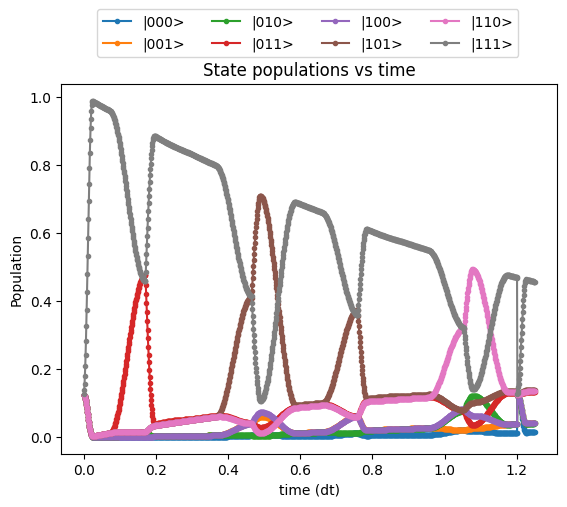

In [14]:
# plot the states to check that they make sense 
time = np.linspace(0, total_time, len(states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(states)):
        data.append(np.real(qt.ptrace(states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")